# Ejercicio 3 - Problema del Subarreglo Maximo

Notebook para comparar la solucion por fuerza bruta contra la solucion por divide y venceras.


In [69]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt


In [70]:

def subarreglo_maximo_fuerza_bruta(arreglo):
    cantidad = len(arreglo)
    suma_maxima = float("-inf")
    mejor_izquierda, mejor_derecha = 0, 0

    for izquierda in range(cantidad):
        suma_actual = 0
        for derecha in range(izquierda, cantidad):
            suma_actual += arreglo[derecha]
            if suma_actual > suma_maxima:
                suma_maxima = suma_actual
                mejor_izquierda, mejor_derecha = izquierda, derecha

    return mejor_izquierda, mejor_derecha, suma_maxima


def subarreglo_maximo_cruzado(arreglo, inferior, medio, superior):
    suma_izquierda = float("-inf")
    suma = 0
    indice_izquierdo = medio

    for indice in range(medio, inferior - 1, -1):
        suma += arreglo[indice]
        if suma > suma_izquierda:
            suma_izquierda = suma
            indice_izquierdo = indice

    suma_derecha = float("-inf")
    suma = 0
    indice_derecho = medio + 1

    for indice in range(medio + 1, superior + 1):
        suma += arreglo[indice]
        if suma > suma_derecha:
            suma_derecha = suma
            indice_derecho = indice

    return indice_izquierdo, indice_derecho, suma_izquierda + suma_derecha


def subarreglo_maximo_divide_y_venceras(arreglo, inferior, superior):
    if inferior == superior:
        return inferior, superior, arreglo[inferior]

    medio = (inferior + superior) // 2
    izquierda_inf, izquierda_sup, suma_izquierda = subarreglo_maximo_divide_y_venceras(arreglo, inferior, medio)
    derecha_inf, derecha_sup, suma_derecha = subarreglo_maximo_divide_y_venceras(arreglo, medio + 1, superior)
    cruzado_inf, cruzado_sup, suma_cruzada = subarreglo_maximo_cruzado(arreglo, inferior, medio, superior)

    if suma_izquierda >= suma_derecha and suma_izquierda >= suma_cruzada:
        return izquierda_inf, izquierda_sup, suma_izquierda
    if suma_derecha >= suma_izquierda and suma_derecha >= suma_cruzada:
        return derecha_inf, derecha_sup, suma_derecha
    return cruzado_inf, cruzado_sup, suma_cruzada



In [78]:

arreglo_documento = [1, -6, 1, -7, 2, -3, 6, -6, 2, -6]

izquierda, derecha, suma = subarreglo_maximo_fuerza_bruta(arreglo_documento)
print("Fuerza bruta")
print("Subarreglo:", arreglo_documento[izquierda:derecha + 1])
print("Posiciones:", (izquierda, derecha), "Suma:", suma)
print()

izquierda, derecha, suma = subarreglo_maximo_divide_y_venceras(arreglo_documento, 0, len(arreglo_documento) - 1)
print("Divide y venceras")
print("Subarreglo:", arreglo_documento[izquierda:derecha + 1])
print("Posiciones:", (izquierda, derecha), "Suma:", suma)

Fuerza bruta
Subarreglo: [6]
Posiciones: (6, 6) Suma: 6

Divide y venceras
Subarreglo: [6]
Posiciones: (6, 6) Suma: 6


## Verificacion con el arreglo base


In [76]:
TAMANOS = [10, 50, 100, 200, 500, 1000]
REPETICIONES = 30


def medir_tiempos(tamanos, repeticiones):
    tiempos_bruta = []
    tiempos_divide = []

    for tamano in tamanos:
        total_bruta = 0.0
        total_divide = 0.0

        for _ in range(repeticiones):
            arreglo = [random.randint(-100, 100) for _ in range(tamano)]

            inicio = time.perf_counter()
            subarreglo_maximo_fuerza_bruta(arreglo)
            total_bruta += time.perf_counter() - inicio

            inicio = time.perf_counter()
            subarreglo_maximo_divide_y_venceras(arreglo, 0, tamano - 1)
            total_divide += time.perf_counter() - inicio

        tiempos_bruta.append((total_bruta / repeticiones) * 1000)
        tiempos_divide.append((total_divide / repeticiones) * 1000)

    return {
        "tamanos": tamanos,
        "tiempos_bruta": tiempos_bruta,
        "tiempos_divide": tiempos_divide,
    }


resultados = medir_tiempos(TAMANOS, REPETICIONES)

Tamano   10 | Fuerza bruta: 0.0153 ms | Divide y venceras: 0.0661 ms
Tamano   50 | Fuerza bruta: 0.1494 ms | Divide y venceras: 0.5245 ms
Tamano  100 | Fuerza bruta: 0.5607 ms | Divide y venceras: 0.5980 ms
Tamano  200 | Fuerza bruta: 1.8660 ms | Divide y venceras: 1.0227 ms
Tamano  500 | Fuerza bruta: 12.5955 ms | Divide y venceras: 2.6565 ms
Tamano 1000 | Fuerza bruta: 49.3630 ms | Divide y venceras: 6.2647 ms


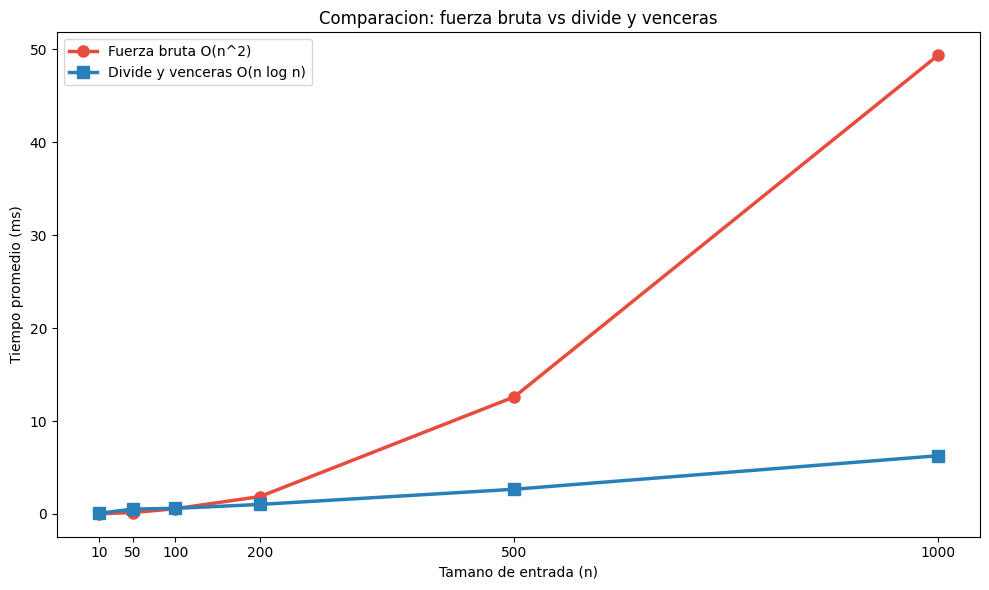

Grafica guardada en: /Users/darwin/Downloads/Momento Evaluativo 2/grafica_subarreglo.png


In [77]:
for tamano, bruta, divide in zip(resultados["tamanos"], resultados["tiempos_bruta"], resultados["tiempos_divide"]):
    print(f"Tamano {tamano:4d} | Fuerza bruta: {bruta:.4f} ms | Divide y venceras: {divide:.4f} ms")

figura, eje = plt.subplots(figsize=(10, 6))

eje.plot(resultados["tamanos"], resultados["tiempos_bruta"], marker="o", linewidth=2.5, markersize=8,
         color="#E74C3C", label="Fuerza bruta O(n^2)")
eje.plot(resultados["tamanos"], resultados["tiempos_divide"], marker="s", linewidth=2.5, markersize=8,
         color="#2980B9", label="Divide y venceras O(n log n)")

eje.set_title("Comparacion: fuerza bruta vs divide y venceras")
eje.set_xlabel("Tamano de entrada (n)")
eje.set_ylabel("Tiempo promedio (ms)")
eje.legend()
eje.set_xticks(TAMANOS)

plt.tight_layout()
ruta_salida = Path("grafica_subarreglo.png")
plt.savefig(ruta_salida, dpi=150, bbox_inches="tight")
plt.show()

print(f"Grafica guardada en: {ruta_salida.resolve()}")